# Lab 2: Robot Motion Planning and Control

## Introduction
This laboratory work investigates the modeling, kinematic analysis, and trajectory planning of the UR5 industrial manipulator using the Robotics Toolbox for Python.

Modern robotic systems require accurate modeling of motion and dynamics in order to perform tasks efficiently and safely. This lab integrates forward kinematics, inverse kinematics, and trajectory generation to simulate realistic robotic motion.

The UR5 robot is widely used in industrial automation, making it a suitable platform for studying real-world robotic behavior.

## Objectives

The main objectives of this laboratory work are:

- Load and configure the UR5 robot model
- Define its kinematic and dynamic parameters
- Select a valid initial joint configuration
- Solve the forward kinematics problem
- Construct the workspace of the manipulator
- Solve the inverse kinematics problem for a target point
- Plan trajectories using three different methods
- Analyze motion using position, velocity, and acceleration plots

In [313]:
# import libs 
import pandas as pd
from math import pi 
import numpy as np 
import roboticstoolbox as rtb 
import spatialmath.base as sb
import matplotlib.pyplot as plt


## Robot Model and DH Representation

The UR5 manipulator is modeled using the Denavit–Hartenberg (DH) convention.

Each link is defined by four parameters:

- Link length: $a_i$
- Link offset: $d_i$
- Link twist: $\alpha_i$
- Joint angle: $\theta_i$

These parameters define the geometric relationship between consecutive links and allow the computation of transformations along the kinematic chain.

In [314]:
#load model UR5 
robot=rtb.models.DH.UR5()

In [315]:
#show parametrs & DH 
print(robot)


DHRobot: UR5 (by Universal Robotics), 6 joints (RRRRRR), dynamics, standard DH parameters
┌─────┬─────────┬─────────┬────────┐
│ θⱼ  │   dⱼ    │   aⱼ    │   ⍺ⱼ   │
├─────┼─────────┼─────────┼────────┤
│  q1 │ 0.08946 │       0 │  90.0° │
│  q2 │       0 │  -0.425 │   0.0° │
│  q3 │       0 │ -0.3922 │   0.0° │
│  q4 │  0.1091 │       0 │  90.0° │
│  q5 │ 0.09465 │       0 │ -90.0° │
│  q6 │  0.0823 │       0 │   0.0° │
└─────┴─────────┴─────────┴────────┘

┌──┬──┐
└──┴──┘

┌──────┬───────┬─────┬─────┬─────┬──────┬─────┐
│ name │ q0    │ q1  │ q2  │ q3  │ q4   │ q5  │
├──────┼───────┼─────┼─────┼─────┼──────┼─────┤
│   qr │  180° │  0° │  0° │  0° │  90° │  0° │
│   qz │  0°   │  0° │  0° │  0° │  0°  │  0° │
└──────┴───────┴─────┴─────┴─────┴──────┴─────┘



## Robot Dynamics

The dynamic behavior of the manipulator is described by:

$$
\tau = M(q)\ddot{q} + C(q, \dot{q})\dot{q} + G(q) + F
$$

Where:

- $M(q)$: inertia matrix
- $C(q, \dot{q})$: Coriolis and centrifugal effects
- $G(q)$: gravity vector
- $F$: friction forces

Friction is modeled as:

$$
F = B\dot{q} + \tau_c
$$

Where:

- $B$: viscous friction coefficient
- $\tau_c$: Coulomb friction

The Coulomb friction is defined as:

$$
\tau_c =
\begin{cases}
T_c^+ & \dot{q} > 0 \\
T_c^- & \dot{q} < 0
\end{cases}
$$

This model captures both velocity-dependent and constant friction effects.

- mass : 


In [316]:
robot.links[0].m=3.7
robot.links[1].m=8.393
robot.links[2].m=2.275
robot.links[3].m=1.129
robot.links[4].m=1.129
robot.links[5].m=0.1879

- Centers of mass : 


In [317]:
robot.links[0].r=[0,-0.02561,0.00193]
robot.links[1].r=[0.2125, 0, 0.11336]
robot.links[2].r=[0.15,0, 0.0265]
robot.links[3].r=[0,-0.0018, 0.01634]
robot.links[4].r=[0, 0.0018, 0.01634]
robot.links[5].r=[0, 0, -0.00116]

- Inertia tensors : 

In [318]:
robot.links[0].I = [0.0067,0.0064,0.0067, 0, 0, 0]
robot.links[1].I = [0.0149,0.3564,0.3553, 0, 0, 0]
robot.links[2].I = [0.0025,0.0551,0.0546, 0, 0.0034, 0]
robot.links[3].I = [0.0012,0.0012,0.0009, 0, 0, 0]
robot.links[4].I = [0.0012,0.0012,0.0009, 0, 0, 0]
robot.links[5].I = [0.0001,0.0001,0.0001, 0, 0, 0]

- Motors inertias :

In [319]:
robot.links[0].Jm = 0.000188
robot.links[1].Jm = 0.000188
robot.links[2].Jm = 0.000188
robot.links[3].Jm = 2.08e-5
robot.links[4].Jm = 2.08e-5
robot.links[5].Jm = 2.08e-5

- Friction coefficients : 

In [320]:
robot.links[0].B = 0.02
robot.links[1].B = 0.02
robot.links[2].B = 0.02
robot.links[3].B = 0.005
robot.links[4].B = 0.005
robot.links[5].B = 0.005

- Coulomb friction coefficients :

In [321]:
robot.links[0].Tc = [0.076, -0.076]
robot.links[1].Tc = [0.083, -0.082]
robot.links[2].Tc = [0.078, -0.077]
robot.links[3].Tc = [0.014, -0.014]
robot.links[4].Tc = [0.02, -0.019]
robot.links[5].Tc = [0.021, -0.021]

- Gear ratios : 

In [322]:
robot.links[0].G = 101
robot.links[1].G = 101
robot.links[2].G = 101
robot.links[3].G = 101
robot.links[4].G = 101
robot.links[5].G = 101

- Joints Limits : 


In [323]:
robot.links[0].qlim = [-2*np.pi, 2*np.pi]
robot.links[1].qlim = [-2*np.pi, 2*np.pi]
robot.links[2].qlim = [-2*np.pi, 2*np.pi]
robot.links[3].qlim = [-2*np.pi, 2*np.pi]
robot.links[4].qlim = [-2*np.pi, 2*np.pi]
robot.links[5].qlim = [-2*np.pi, 2*np.pi]

## Initial Configuration

An arbitrary initial joint configuration is selected:

$$
q_{start} = [q_1, q_2, q_3, q_4, q_5, q_6]
$$

The configuration is chosen to avoid singularities and ensure a valid starting pose for motion planning.

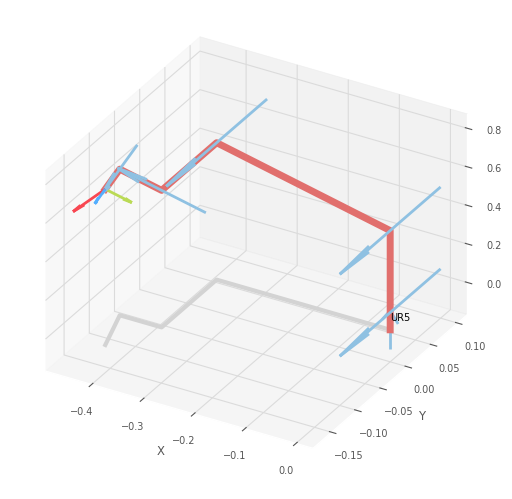

<Figure size 640x480 with 0 Axes>

In [324]:
#q_start=[pi/4, -pi/3, -pi/4, pi/3, -pi/3, pi/4]

q_start=[0, -np.pi/2, np.pi/3, -np.pi/2, np.pi/4, 0]
robot.plot(q_start)  
plt.show()

## Forward Kinematics

Forward kinematics determines the position and orientation of the end-effector based on joint variables.

The homogeneous transformation matrix between two consecutive links is defined as:

$$
T_i^{i-1} =
\begin{bmatrix}
\cos\theta_i & -\sin\theta_i \cos\alpha_i & \sin\theta_i \sin\alpha_i & a_i \cos\theta_i \\
\sin\theta_i & \cos\theta_i \cos\alpha_i & -\cos\theta_i \sin\alpha_i & a_i \sin\theta_i \\
0 & \sin\alpha_i & \cos\alpha_i & d_i \\
0 & 0 & 0 & 1
\end{bmatrix}
$$

The overall transformation from base to end-effector is:

$$
T = \prod_{i=1}^{n} T_i^{i-1}
$$

This matrix fully describes the pose (position and orientation) of the robot end-effector in Cartesian space.

In [325]:
#FK for start point 
T_start=robot.fkine(q_start)
print(T_start)

  -0.3536    0.866     0.3536   -0.3926    
  -0.7071    0        -0.7071   -0.1673    
  -0.6124   -0.5       0.6124    0.8083    
   0         0         0         1         



## Workspace Construction

The workspace represents all reachable positions of the end-effector.

It is approximated by sampling the joint limits:

$$
q_i \in [q_{min}, q_{max}]
$$

The Cartesian position is computed using forward kinematics:

$$
p = f(q)
$$

Only the first three joints are sampled since they primarily determine the spatial position of the end-effector, while the remaining joints mainly affect orientation.

The resulting point cloud provides a visualization of the robot workspace.

In [326]:
n=20 # number of sample in each statue 
i=0 # for count
move=[np.linspace(robot.links[i].qlim[0],robot.links[i].qlim[1],n) for i in range(3)] # make samples for the first 3 joint 
pose=np.zeros([3,n**3]) # for save the pos 


In [327]:
# Studying all cases and calculate Forward Kinimatic 
for q1 in move[0]:
    for q2 in move[1]:
        for q3 in move[2]:
            Tt =robot.fkine([q1,q2,q3,0,0,0])
            for j in range(3):
                pose[j][i]=Tt.t[j] #position in each case
            i+=1


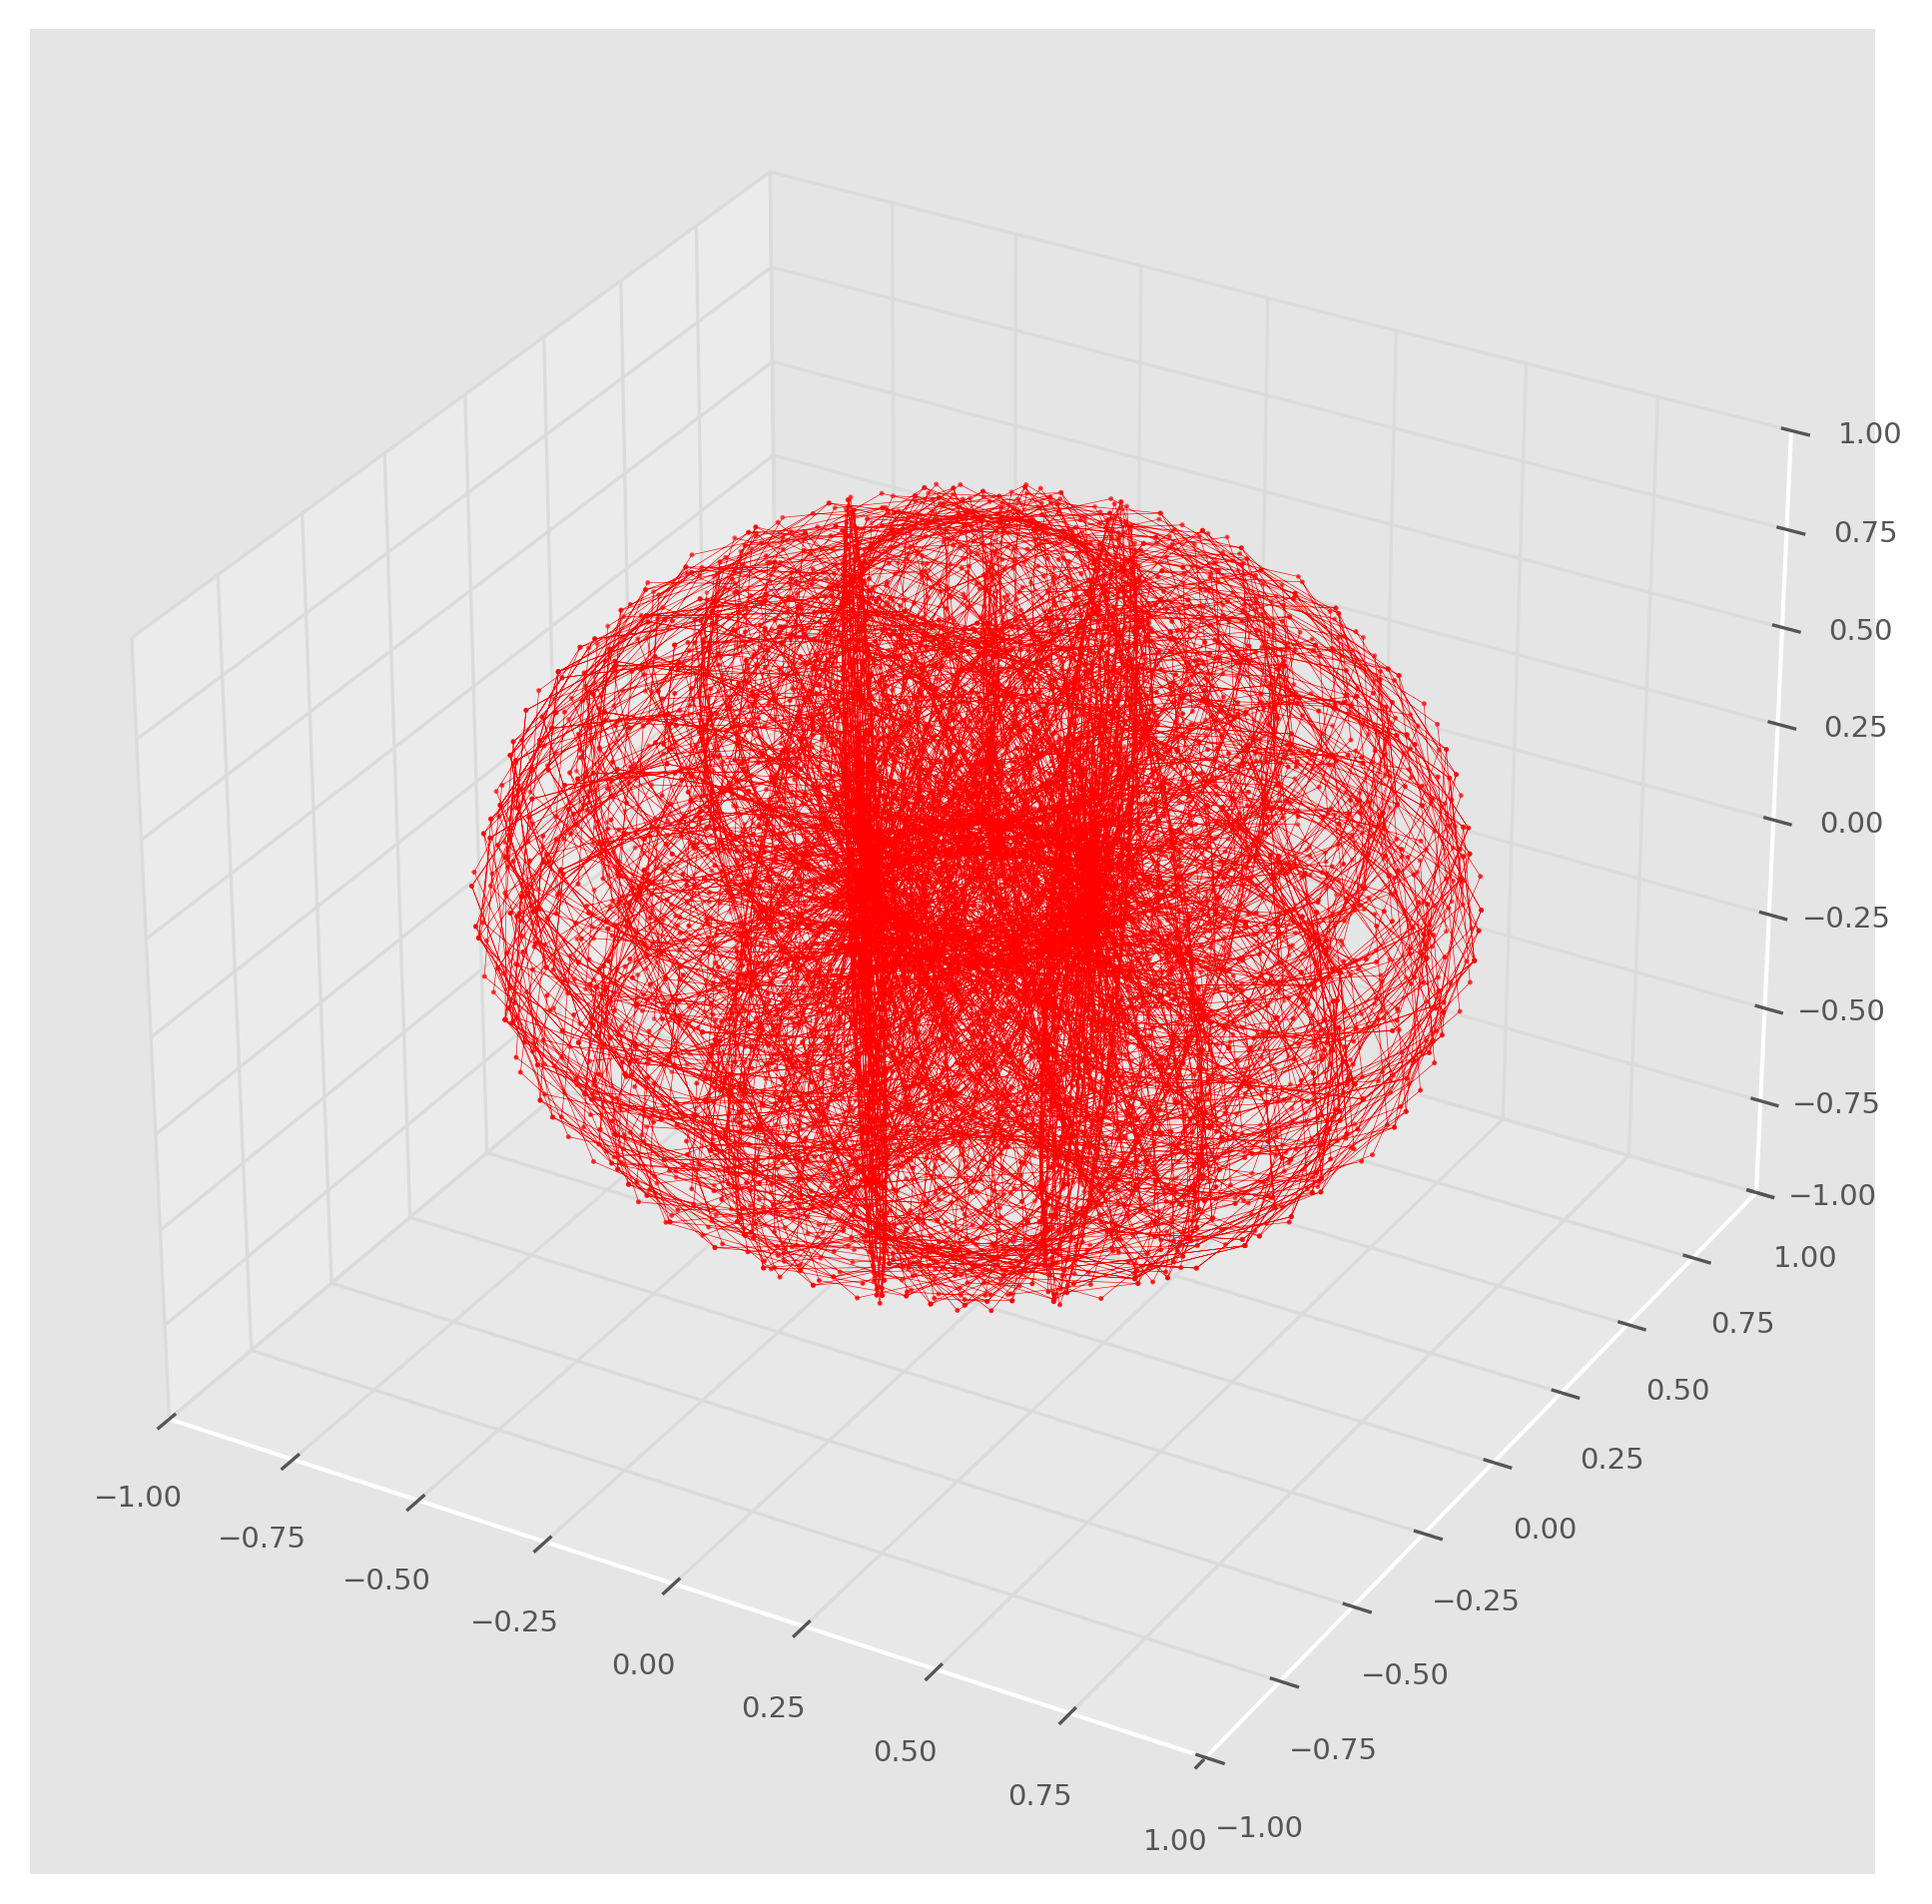

In [328]:
# make 3D workspace

plt.figure(figsize=(8,8),dpi=300)
ax=plt.axes(projection="3d")
ax.plot3D(pose[0],pose[1],pose[2],color='red',linewidth=0.15)
ax.scatter3D(pose[0],pose[1],pose[2],s=0.5,color='red')
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
ax.set_zlim(-1,1)
plt.show()


## Inverse Kinematics

Inverse kinematics determines the joint configuration required to reach a desired end-effector pose:

$$
q = f^{-1}(T)
$$

Where $T$ is the desired transformation matrix.

This problem may have multiple solutions or no solution depending on the target position and robot constraints. A valid solution is selected for trajectory planning.

IKSolution: q=[-0.4131, -1.054, 2.109, -2.626, 1.571, 1.984], success=True, iterations=8, searches=1, residual=5.41e-12
Inverse kinematics solution found:
[-0.41312576 -1.05394538  2.10908472 -2.62593567  1.57079633  1.98392209]


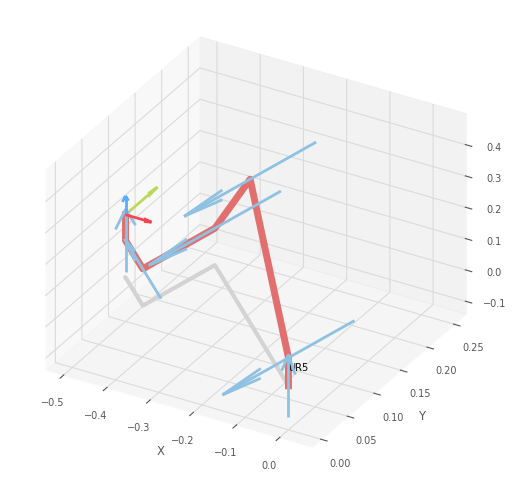

<Figure size 640x480 with 0 Axes>

In [329]:
#detect point form WorkSpace
point=[-0.5,0.1,0.2]
T_end=sb.transl(point) # using Spatal math to make transformation matirx 
# inverse Kinenmatics 
ik_solution=robot.ikine_GN(T_end,q0=q_start)

print(ik_solution)

# check the solution if it is success 
if ik_solution.success:
    q_end = ik_solution.q # take the angels for the detected pose 
    print("Inverse kinematics solution found:")
    print(q_end)
else:
    raise ValueError("Inverse kinematics failed. Choose another target point.")

robot.plot(q_end)
plt.show()



## Trajectory Planning

The objective is to generate a smooth trajectory between:

$$
q_{start} \rightarrow q_{end}
$$

### 1. Polynomial Trajectory (jtraj)

$$
q(t) = a_0 + a_1 t + a_2 t^2 + a_3 t^3
$$

Provides smooth interpolation in joint space.

---

### 2. Trapezoidal Velocity Profile

$$
v(t) =
\begin{cases}
a t & t < t_1 \\
v_{max} & t_1 \le t \le t_2 \\
v_{max} - a(t-t_2) & t > t_2
\end{cases}
$$

Efficient for time-optimal motion.

---

### 3. Quintic Polynomial

$$
q(t) = a_0 + a_1 t + a_2 t^2 + a_3 t^3 + a_4 t^4 + a_5 t^5
$$

Ensures smooth position, velocity, and acceleration.

---

### 4. Cartesian Straight-Line Trajectory

In addition to joint-space trajectory planning methods, a Cartesian straight-line trajectory is implemented.

Unlike joint-space interpolation, the Cartesian method directly interpolates the end-effector pose between the initial and final configurations:

$$
T(s) = interpolation(T_{start}, T_{goal}), \quad s \in [0,1]
$$

For each interpolated pose, inverse kinematics is solved:

$$
q(s) = IK(T(s))
$$

This method provides better control over the geometric path of the end-effector, but it may produce less smooth joint trajectories because inverse kinematics is solved at each trajectory point.

In [330]:
N=100
#detected time 
t_start=0
t_stop=5
t_shag=t_stop/N
time=np.arange(t_start,t_stop,t_shag)
#Ploynominal Trajectory
tr_jtraj=rtb.jtraj(q_start,q_end,time)

In [331]:
# Trapezoidal Velocity Profile 
tr_trap=rtb.mtraj(rtb.trapezoidal,q_start,q_end,time)


In [332]:
# Quintic Polynominal 
tr_quin=rtb.mtraj(rtb.quintic,q_start,q_end,time)


In [333]:
# Cartesian Straight-Line Trajectory 
q_start = np.array(q_start, dtype=float)
q_end = np.array(q_end, dtype=float)

N = len(time)

T_start = robot.fkine(q_start)
T_goal = robot.fkine(q_end)

q_cart = []
success_flags = []
q_guess = q_start.copy()

# Smooth time scaling: s starts and ends with zero velocity
s_profile = rtb.quintic(0, 1, time).q

for s in s_profile:

    T_s = T_start.interp(T_goal, s)

    sol = robot.ikine_GN(T_s, q0=q_guess)

    if sol.success:
        q_new = sol.q

        q_new = np.unwrap(
            np.vstack([q_guess, q_new]),
            axis=0
        )[1]

        q_cart.append(q_new)
        q_guess = q_new.copy()
        success_flags.append(True)

    else:
        q_cart.append(q_guess.copy())
        success_flags.append(False)

q_cart = np.array(q_cart)

dt = time[1] - time[0]
qd_cart = np.gradient(q_cart, dt, axis=0)
qdd_cart = np.gradient(qd_cart, dt, axis=0)

print("Cartesian trajectory shape:", q_cart.shape)
print("IK success rate:", sum(success_flags), "/", N)
print("Cartesian start velocity:", qd_cart[0])
print("Cartesian end velocity:", qd_cart[-1])

Cartesian trajectory shape: (100, 6)
IK success rate: 100 / 100
Cartesian start velocity: [-0.0001003  -0.00013233  0.0005571  -0.00057405  0.00025604  0.00050231]
Cartesian end velocity: [-8.92020443e-05  2.68244118e-04 -2.20220344e-05 -3.99493768e-05
 -4.23491784e-05  4.24519027e-04]


## Motion Analysis

The motion is analyzed using:

- Position: $q(t)$
- Velocity: $\dot{q}(t)$
- Acceleration: $\ddot{q}(t)$

These metrics describe the kinematic and dynamic behavior of the manipulator during motion.

## Position Analysis

The position plots show that all trajectory methods successfully move the robot from $q_{start}$ to $q_{end}$.

Polynomial-based methods provide smoother transitions, while trapezoidal profiles exhibit linear segments.

The quintic trajectory shows the smoothest behavior near the boundaries.

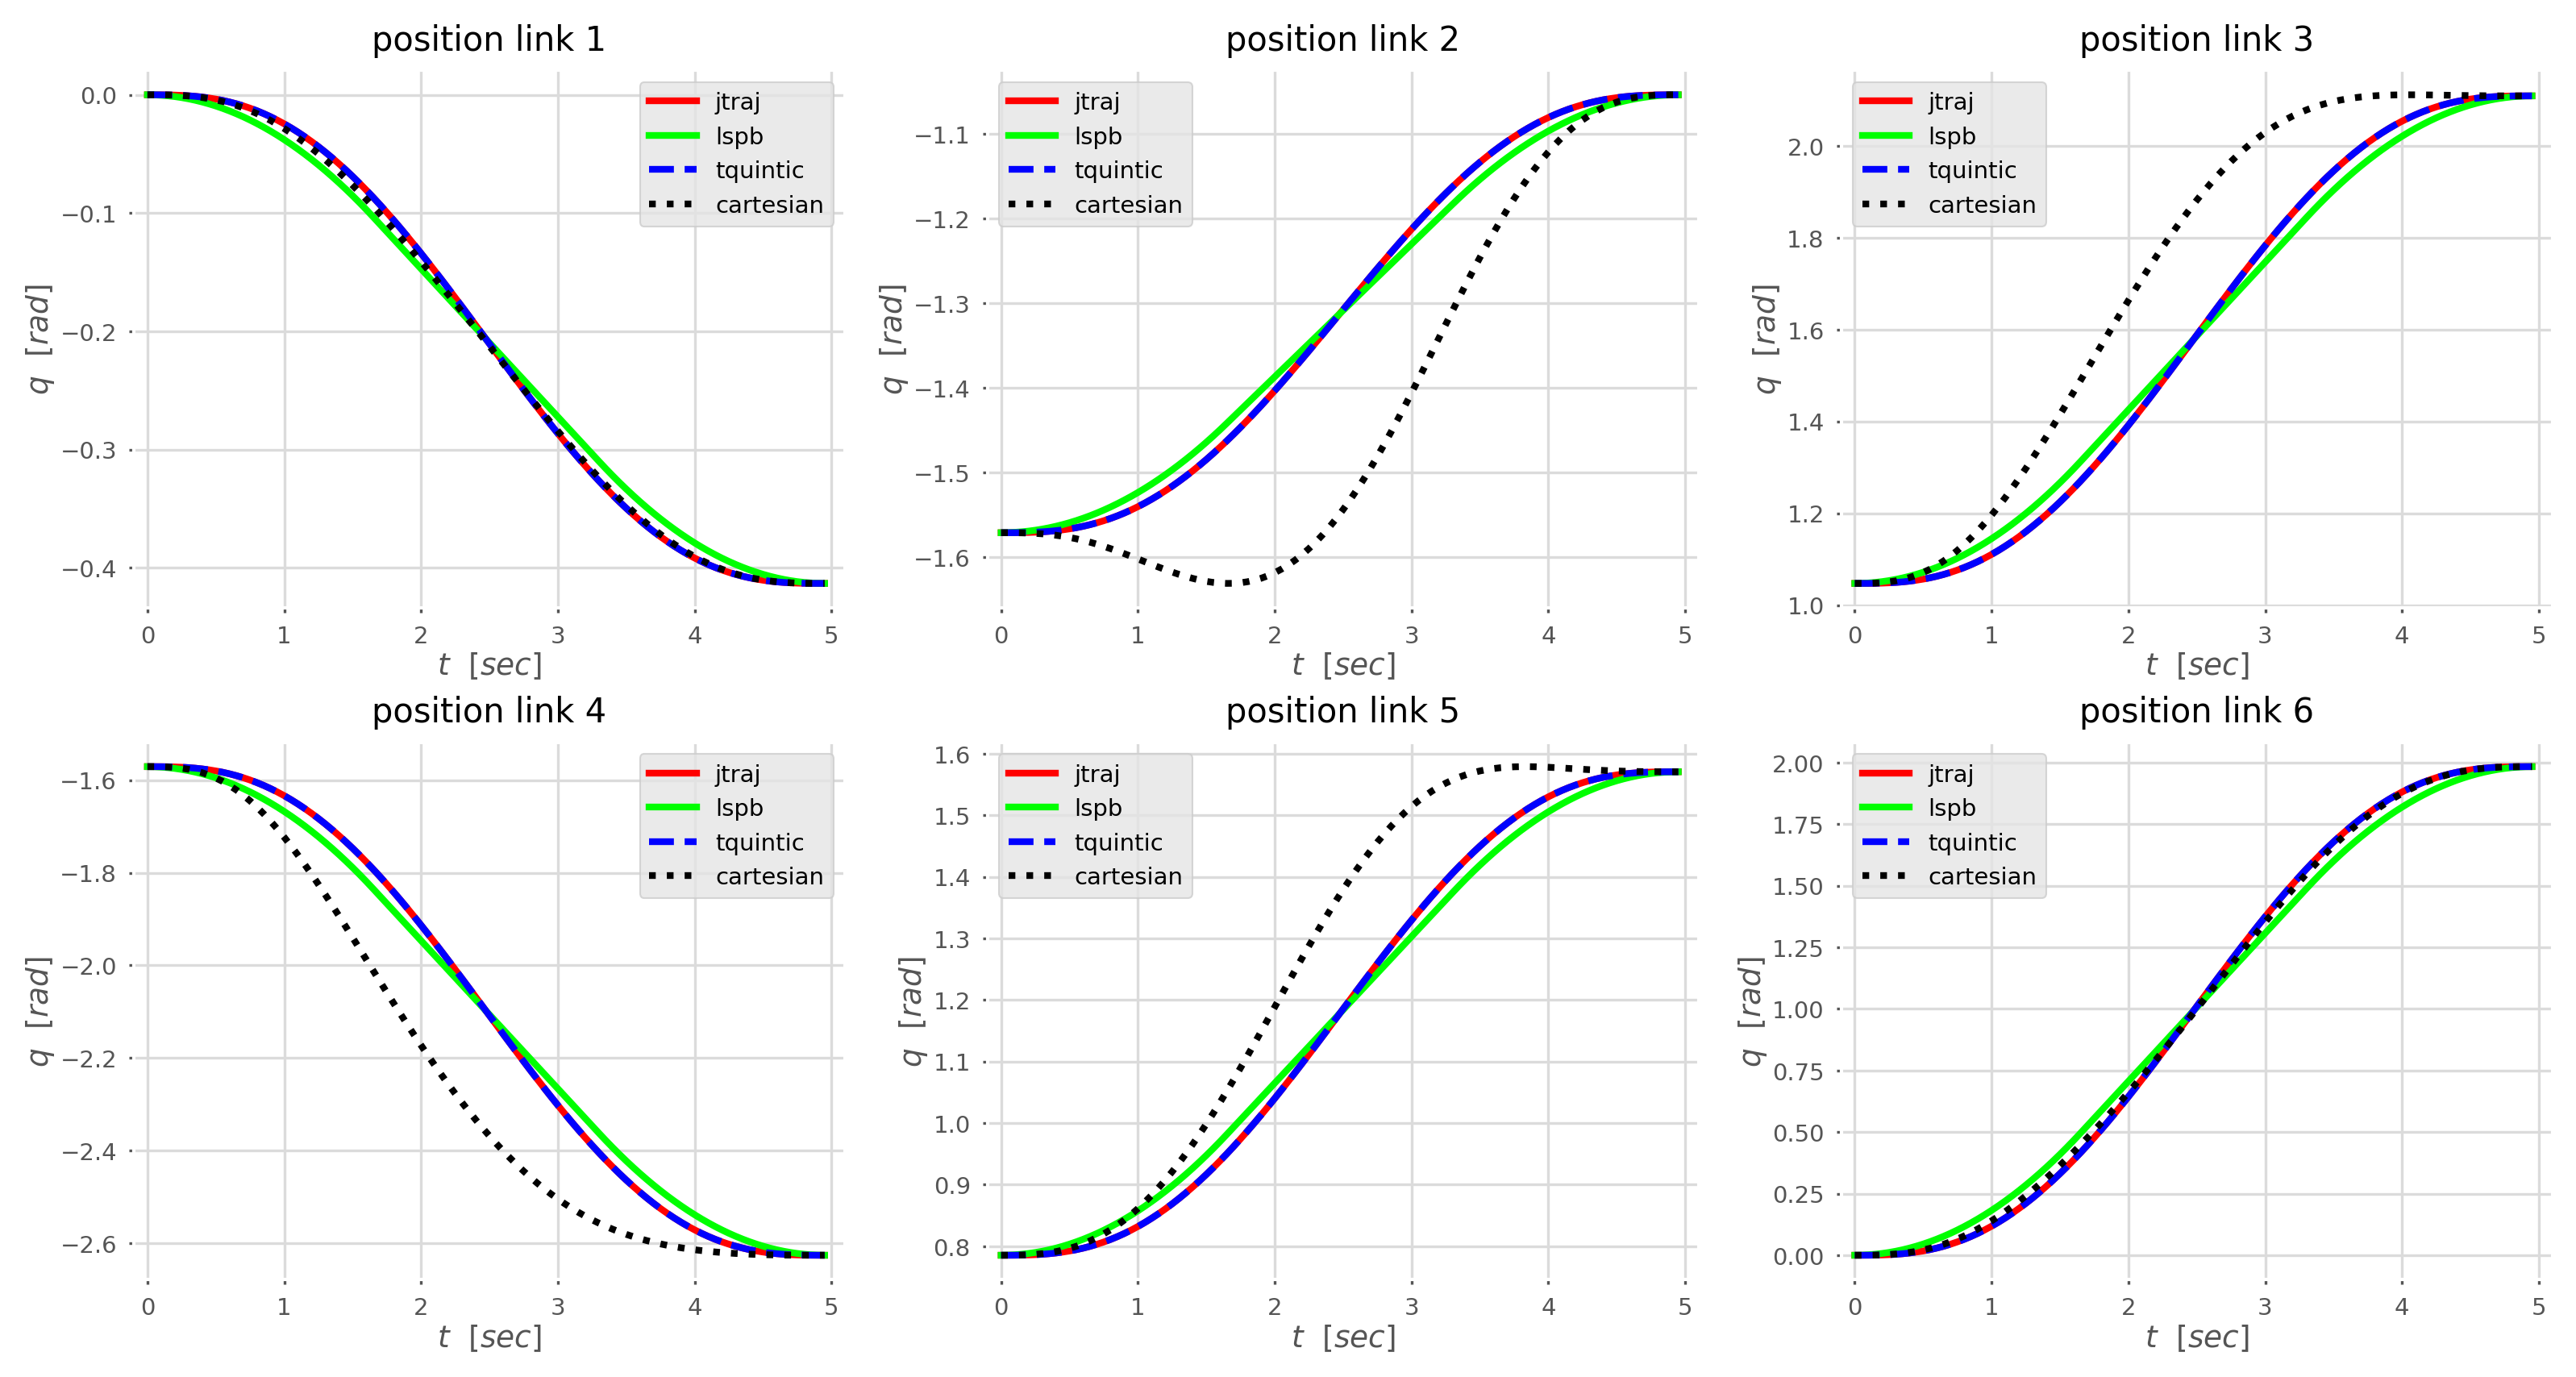

In [ ]:
plt.figure(figsize=(10,5), dpi=300)  # Adjuste the plots 

for g in range(1,7):
# plot for each link 
    plt.subplot(2,3,g)
    plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0.2, hspace=0.25) 

    #get the position data from each method 
    traektoriya_jtraj = [tr_jtraj.q[i][g-1] for i in range(len(tr_jtraj.q))]  
    traektoriya_trap = [tr_trap.q[i][g-1] for i in range(len(tr_trap.q))]  
    traektoriya_quin = [tr_quin.q[i][g-1] for i in range(len(tr_quin.q))]  
    traektoriya_cart = [q_cart[i][g-1] for i in range(len(q_cart))]

    # plot the position with time 
    plt.plot(time, traektoriya_jtraj, linestyle='-', linewidth=2, color=(1,0,0), label=r"jtraj")  
    plt.plot(time, traektoriya_trap, linestyle='-', linewidth=2, color=(0,1,0), label=r"ltrap")  
    plt.plot(time, traektoriya_quin, linestyle='--', linewidth=2, color=(0,0,1), label=r"tquintic")  
    plt.plot(time, traektoriya_cart, linestyle=':', linewidth=2, color=(0,0,0), label=r"cartesian")

    #adjuste the plot for each link 
    plt.title(r"position link {}".format(g), fontsize=10)  
    plt.ylabel(r"$q$  [$rad$]", fontsize=9)  
    plt.xlabel(r"$t$  [$sec$]", fontsize=9)  
    plt.grid(True) 
    plt.legend()  
    ax = plt.gca()  
    ax.set_facecolor((1,1,1))  
    ax.set_xlim([t_start-0.1,t_stop+0.1])  
plt.show()

## Velocity Analysis

Velocity plots reveal:

- Smooth profiles for polynomial methods
- Piecewise behavior for trapezoidal trajectory
- Continuous and smooth transitions for quintic trajectories
- Cartenis 

Smooth velocity reduces mechanical stress on actuators.

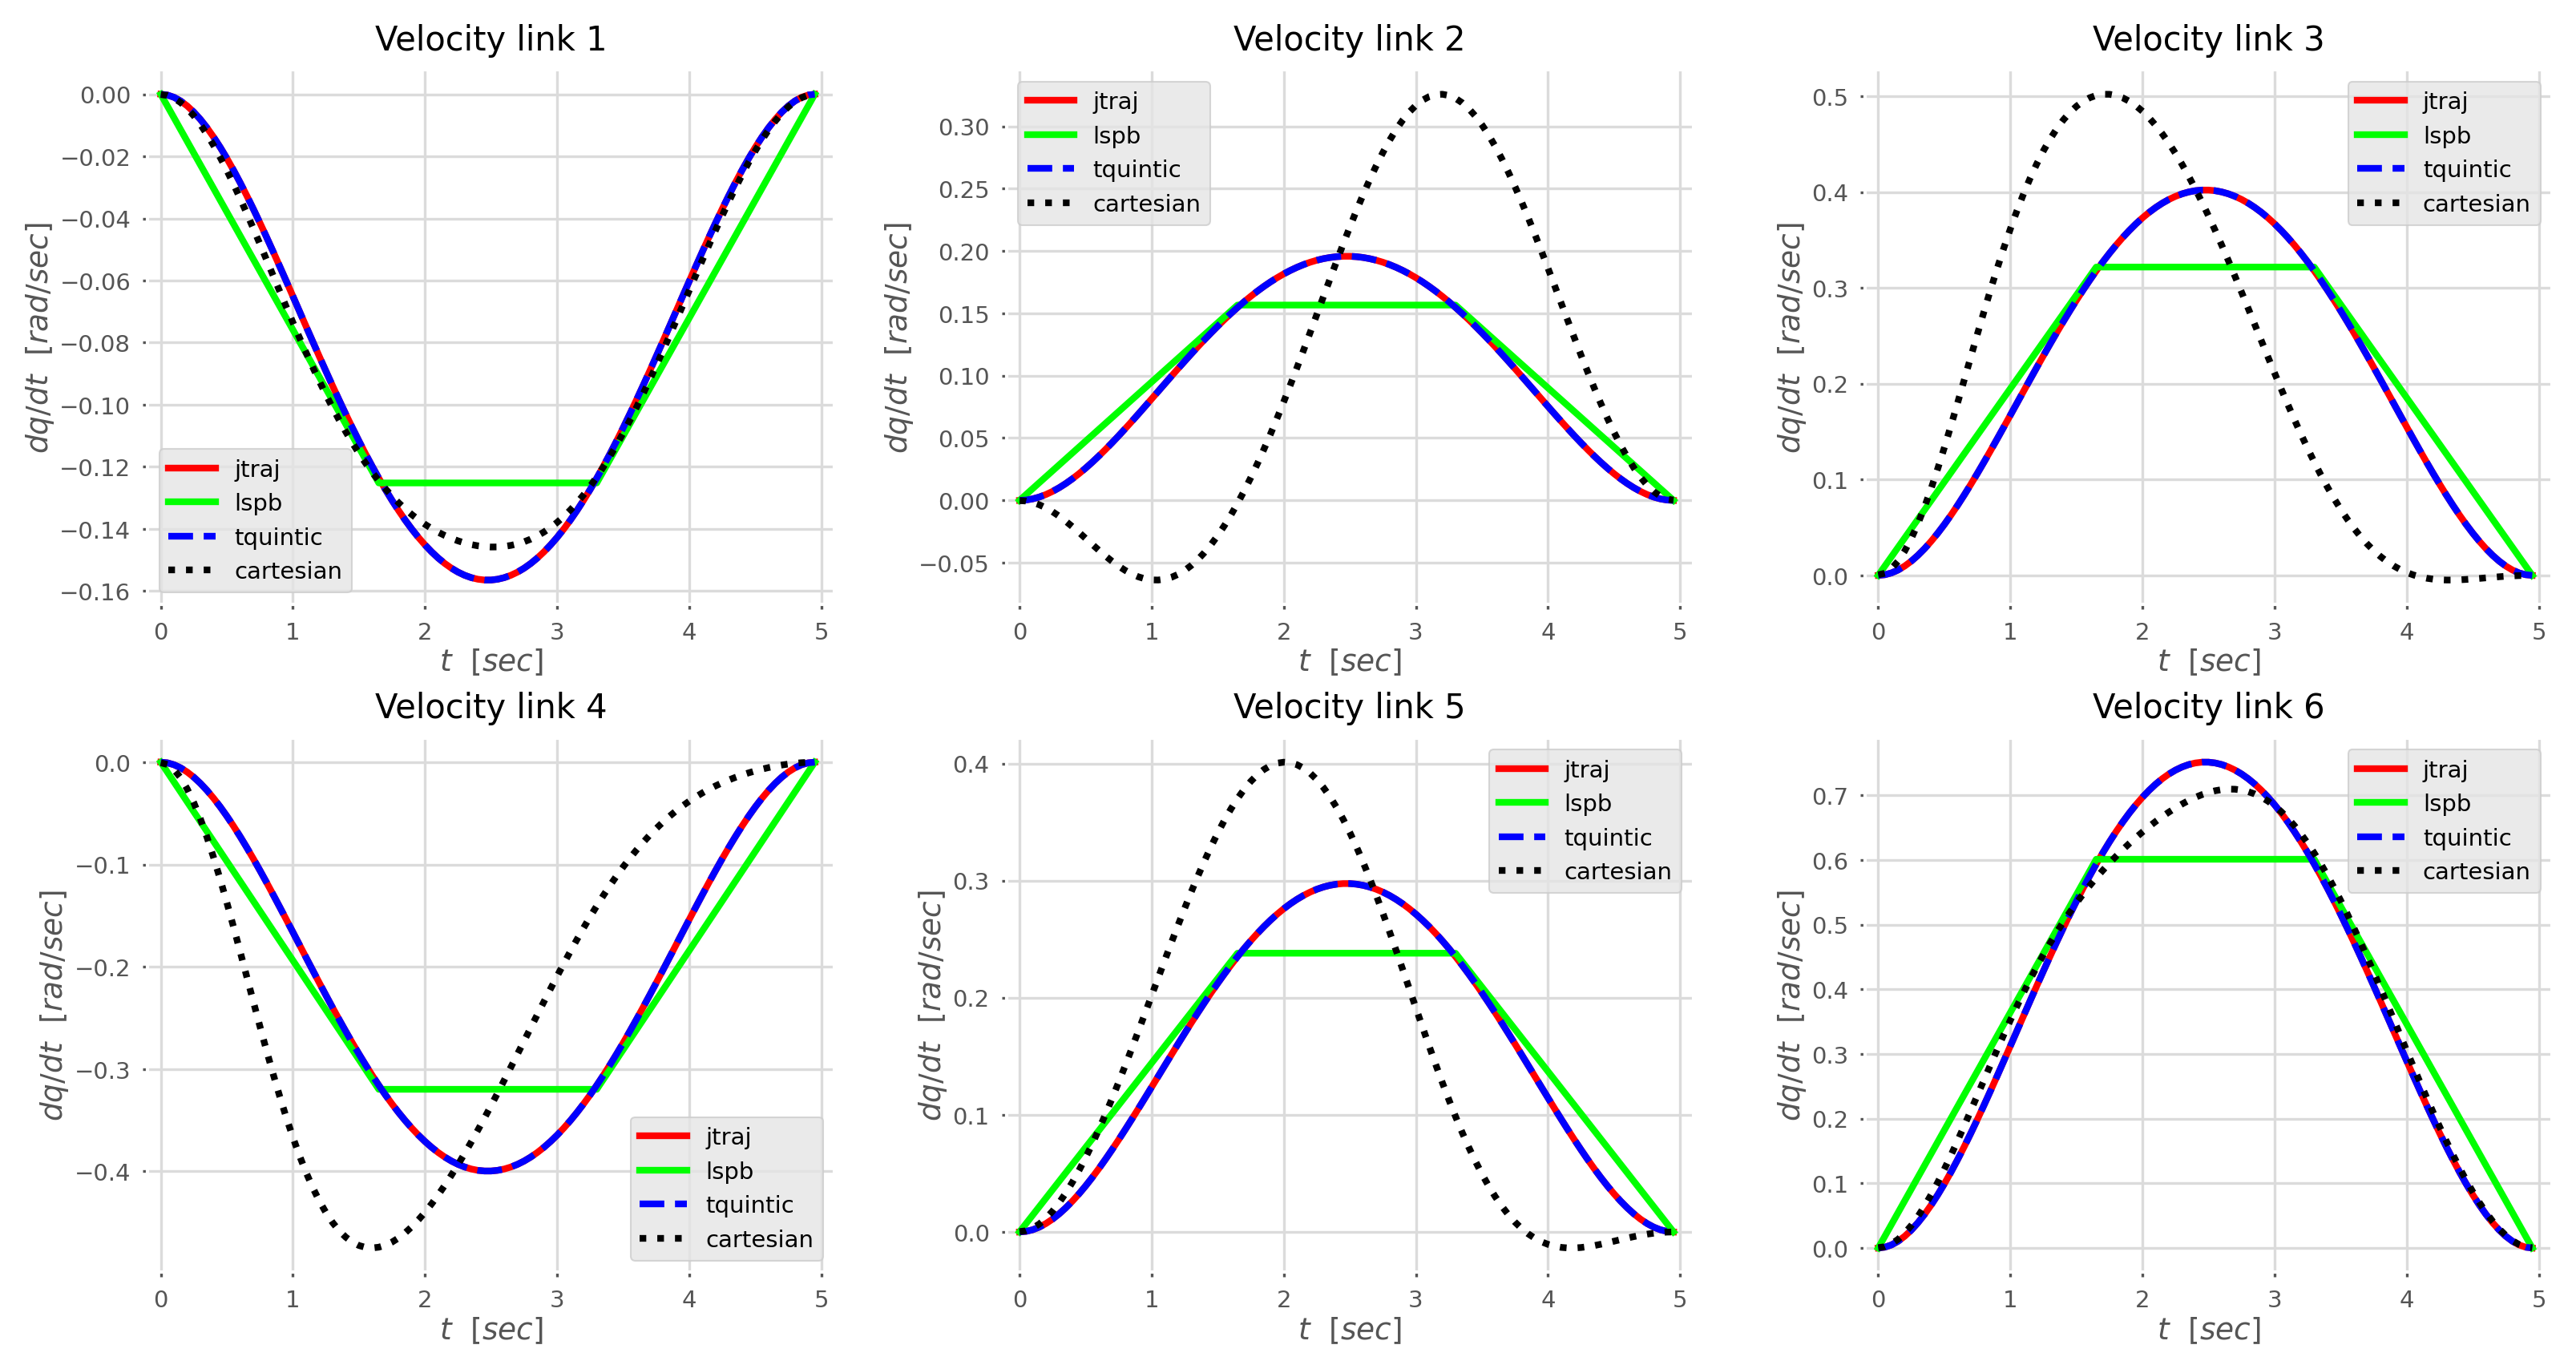

In [ ]:
plt.figure(figsize=(10,5), dpi=300)  
for g in range(1,7):
    # plot for each link 
    plt.subplot(2,3,g)
    plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0.25, hspace=0.25)  

    #get the velocity data from each method
    traektoriya_jtraj = [tr_jtraj.qd[i][g-1] for i in range(len(tr_jtraj.qd))]  
    traektoriya_trap = [tr_trap.qd[i][g-1] for i in range(len(tr_trap.qd))]  
    traektoriya_quin = [tr_quin.qd[i][g-1] for i in range(len(tr_quin.qd))]  
    traektoriya_cart = [qd_cart[i][g-1] for i in range(len(qd_cart))]

    # plot the velocity with time 
    plt.plot(time, traektoriya_jtraj, linestyle='-', linewidth=2, color=(1,0,0), label=r"jtraj")  
    plt.plot(time, traektoriya_trap, linestyle='-', linewidth=2, color=(0,1,0), label=r"ltrap")  
    plt.plot(time, traektoriya_quin, linestyle='--', linewidth=2, color=(0,0,1), label=r"tquintic")  
    plt.plot(time, traektoriya_cart, linestyle=':', linewidth=2, color=(0,0,0), label=r"cartesian")
    
    #adjuste the plot for each link
    plt.title(r"Velocity link {}".format(g), fontsize=10)  
    plt.ylabel(r"$dq/dt$  [$rad/sec$]", fontsize=9)  
    plt.xlabel(r"$t$  [$sec$]", fontsize=9)  
    plt.grid(True)  
    plt.legend()  
    ax = plt.gca()  
    ax.set_facecolor((1,1,1))  
    ax.set_xlim([t_start-0.1,t_stop+0.1]) 
plt.show()

## Acceleration Analysis

Acceleration plots show:

- Discontinuities in trapezoidal trajectories
- Continuous acceleration in quintic trajectories

Smooth acceleration improves system stability and reduces vibration.

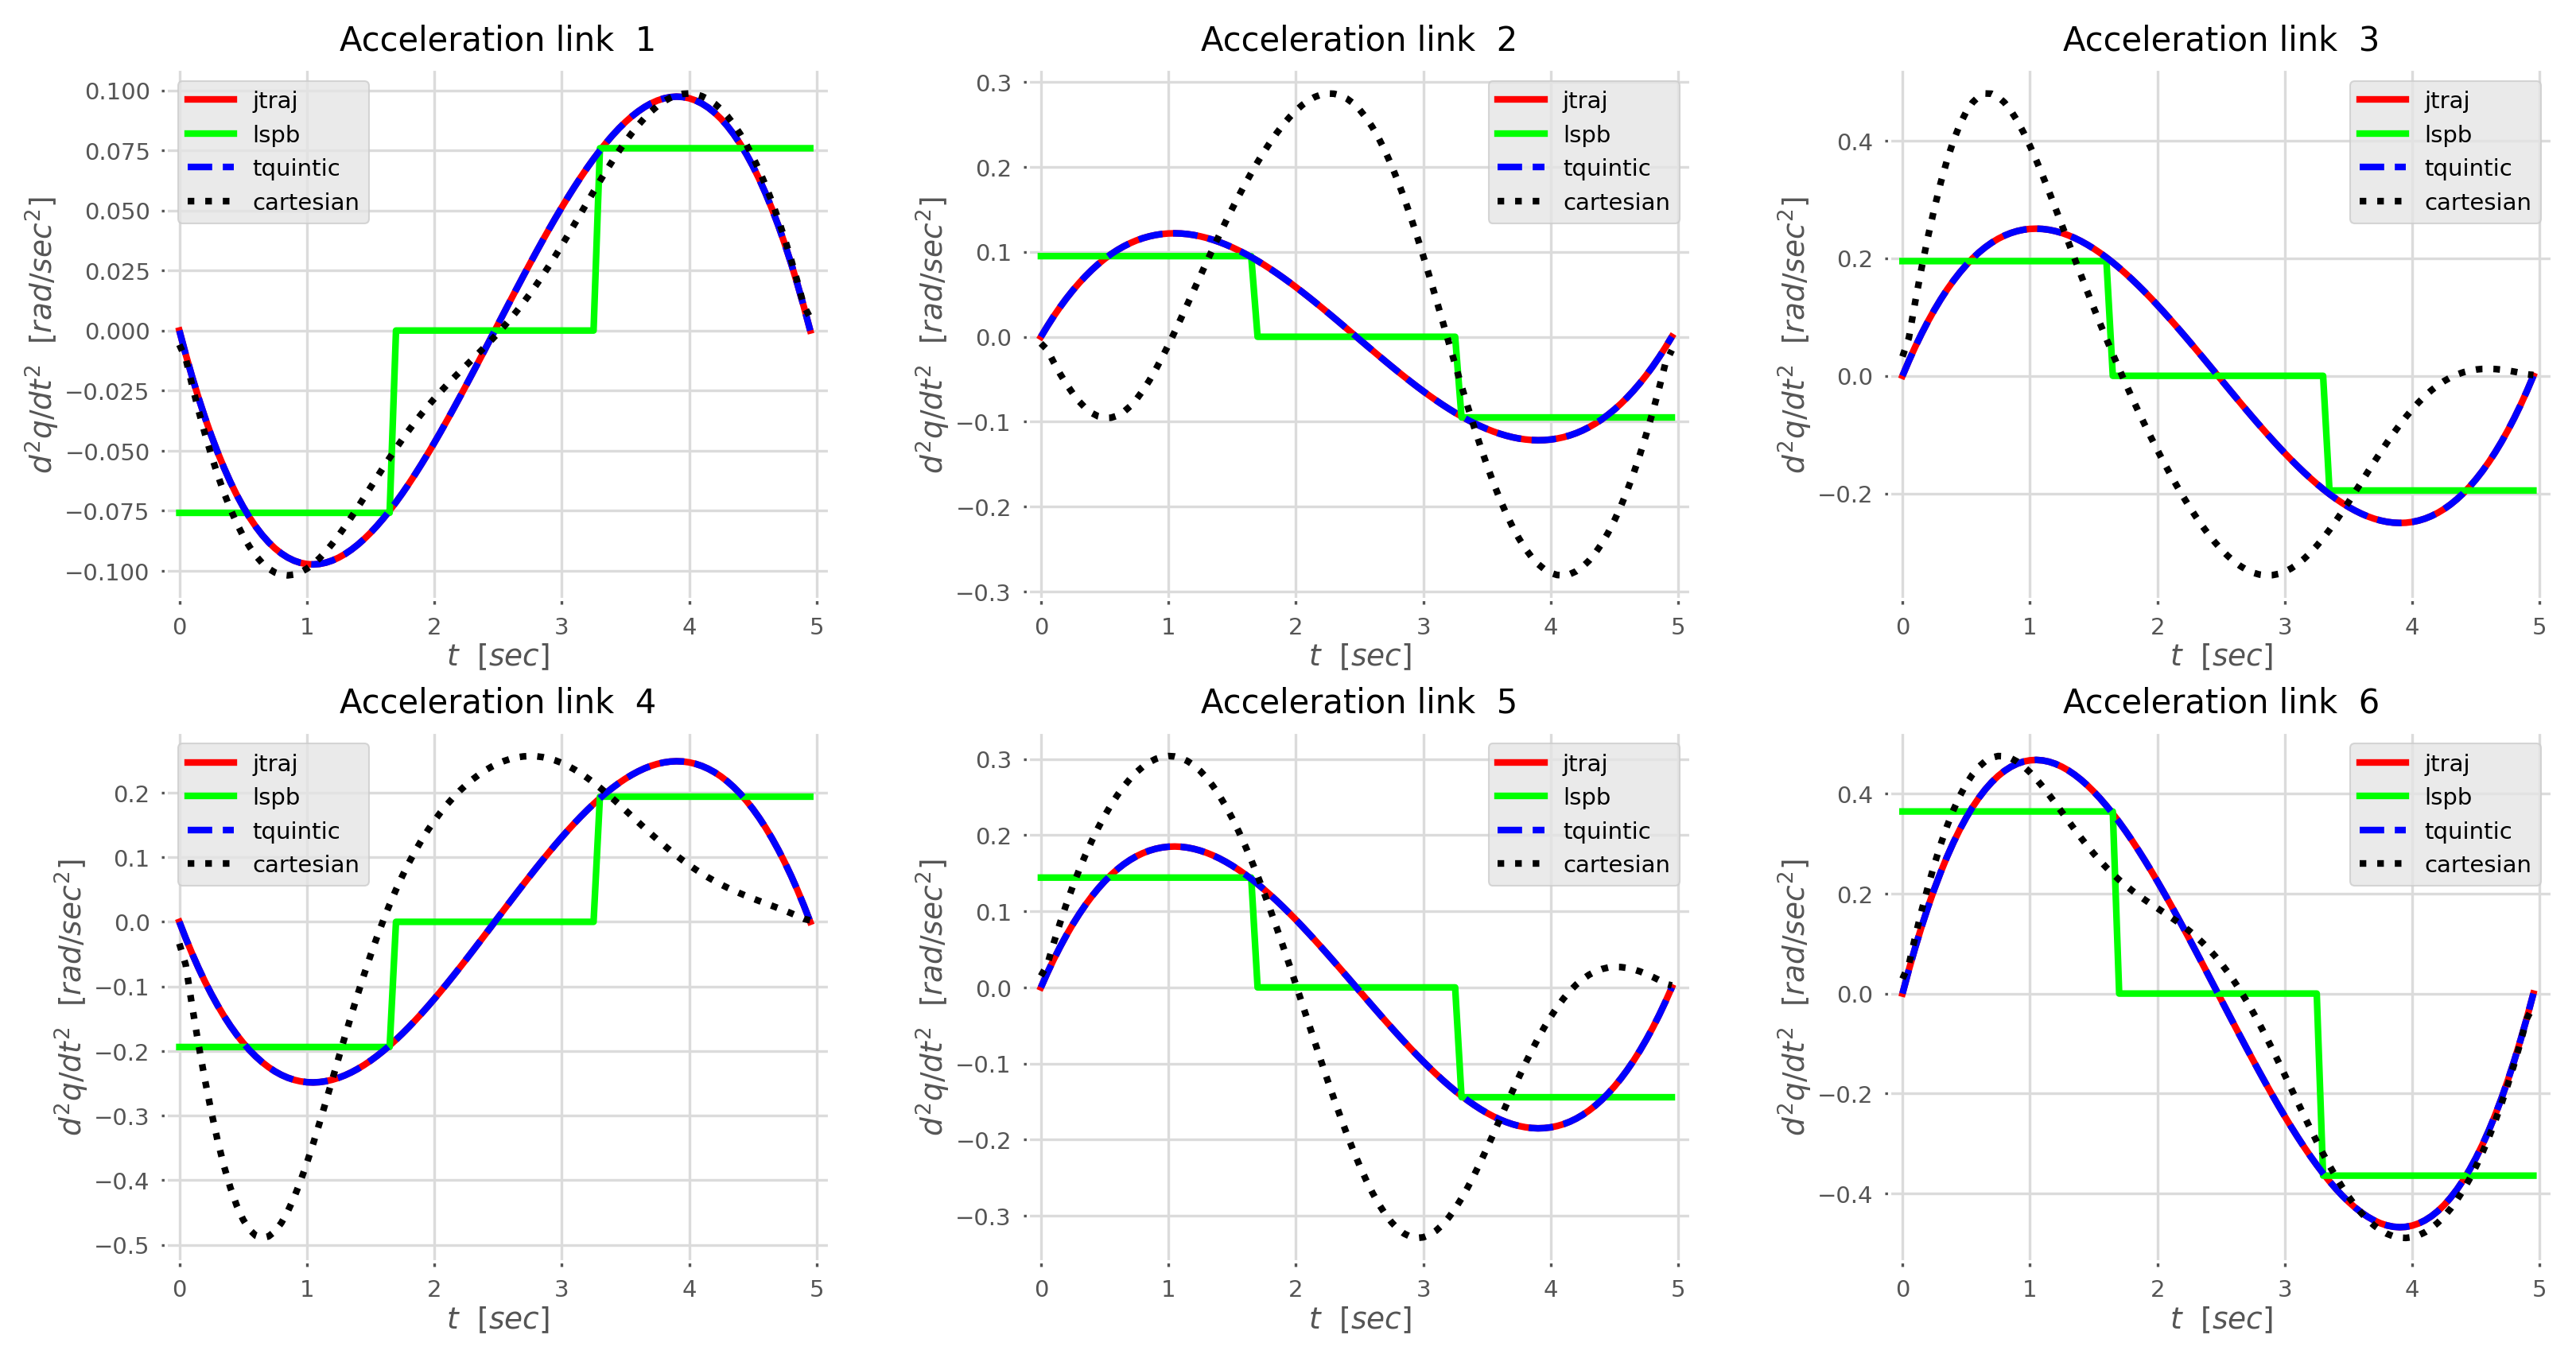

In [ ]:
fig = plt.figure(figsize=(10,5), dpi=300)  
for g in range(1,7):
    # plot for each link
    plt.subplot(2,3,g)
    plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0.3, hspace=0.25)  

    #get the acceleration data from each method
    traektoriya_jtraj = [tr_jtraj.qdd[i][g-1] for i in range(len(tr_jtraj.qdd))]  
    traektoriya_trap = [tr_trap.qdd[i][g-1] for i in range(len(tr_trap.qdd))]  
    traektoriya_quin = [tr_quin.qdd[i][g-1] for i in range(len(tr_quin.qdd))]  
    traektoriya_cart = [qdd_cart[i][g-1] for i in range(len(qdd_cart))]
    
    # plot the acceleration with time 
    plt.plot(time, traektoriya_jtraj, linestyle='-', linewidth=2, color=(1,0,0), label=r"jtraj")  
    plt.plot(time, traektoriya_trap, linestyle='-', linewidth=2, color=(0,1,0), label=r"trap")  
    plt.plot(time, traektoriya_quin, linestyle='--', linewidth=2, color=(0,0,1), label=r"tquintic")  
    plt.plot(time, traektoriya_cart, linestyle=':', linewidth=2, color=(0,0,0), label=r"cartesian")
    
    #adjuste the plot for each link
    plt.title(r"Acceleration link  {}".format(g), fontsize=10)  
    plt.ylabel(r"${d^2}q/d{t^2}$  [$rad/{sec}^2$]", fontsize=9)  
    plt.xlabel(r"$t$  [$sec$]", fontsize=9)  
    plt.grid(True) 
    plt.legend()  
    ax = plt.gca()  
    ax.set_facecolor((1,1,1))  
    ax.set_xlim([t_start-0.1,t_stop+0S.1])  
plt.show()

## Comparative Analysis

The implemented trajectory planning methods show different motion characteristics:

- **jtraj** provides convenient joint-space interpolation with smooth position and velocity profiles.
- **Trapezoidal velocity profile** is simple and efficient, but it introduces sharper acceleration changes.
- **Quintic polynomial trajectory** provides the smoothest joint-space motion because it ensures continuous position, velocity, and acceleration.
- **Cartesian straight-line trajectory** controls the end-effector path directly in Cartesian space, but requires solving inverse kinematics at each trajectory point.

This comparison demonstrates a trade-off between joint-space smoothness and Cartesian path accuracy.

# Conclusion

In this laboratory work, the UR5 manipulator was successfully modeled and analyzed using the Robotics Toolbox for Python.

The robot model was loaded, and the required kinematic and dynamic parameters were defined. An arbitrary initial joint configuration was selected, and forward kinematics was used to compute the initial end-effector pose.

The workspace was approximated by sampling the first three joint limits. A target point was selected inside the workspace, and inverse kinematics was successfully solved to obtain the final joint configuration.

Four trajectory planning methods were implemented and compared: jtraj, trapezoidal velocity profile, quintic polynomial trajectory, and Cartesian straight-line trajectory. Position, velocity, and acceleration plots were generated for all six joints.

The results show that the quintic trajectory provides the smoothest joint-space motion, while the trapezoidal method is simpler but produces sharper acceleration transitions. The Cartesian method provides better control over the end-effector path, but it requires solving inverse kinematics along the trajectory.

Overall, the lab demonstrates that trajectory planning is not only about reaching the target point, but also about selecting a motion profile that satisfies smoothness, stability, and geometric requirements.